# XGBoost model training

In [68]:
#imports

#autoreload utils
# %load_ext autoreload
# %autoreload 2

from utils.modelEvaluation import plot_training_curves, plot_feature_importance, eval_rmse, plot_test_results, calculate_global_test_rmse

### Dataset path defination

In [5]:
#processed data paths

train_processed_path = "../data/processed/train_FD004.csv"
val_processed_path = "../data/processed/validation_FD004.csv"
test_processed_path = "../data/processed/test_FD004.csv"
rul_test_raw_path = "../data/raw/CMAPSSData/RUL_FD004.txt"

In [99]:
%run ../src/data_loader.py

In [ ]:
X_train, y_train, X_val, y_val = xgboost_train_loader(train_path=train_processed_path, val_path=val_processed_path, target_col='target_rul')

### Data loading sanity check

In [8]:
X_train.head()

,op_regime,T24,T30,T50,P30,Nf,Nc,epr,Ps30,NRf,NRc,htBleed
0,5,-0.693905,-1.554268,-1.429294,-0.828586,-0.797788,-1.174632,-1.857537,-0.977167,-0.443547,-0.516716,-0.767811
1,4,-2.472241,-0.887933,-1.357091,-1.467589,-1.660474,-0.878468,-1.406369,-1.415886,-1.907184,-1.373377,-2.277316
2,5,-0.938760,-1.589528,-0.974887,-0.798325,-0.786558,-1.377407,-1.857537,-1.079192,-0.518879,-0.962343,-1.211200
3,5,-1.022615,-1.803366,-0.866800,-0.805706,-0.794045,-1.129522,-0.412956,-1.011175,-0.330549,-0.450496,-1.654590
4,3,-1.654742,-0.935484,-1.763136,-0.908397,-0.910789,-1.440557,-5.356662,-0.861269,-1.031613,-1.035006,-1.271973


In [9]:
y_train.head()

0    125
1    125
2    125
3    125
4    125
Name: target_rul, dtype: int64

In [10]:
X_val.head()

,op_regime,T24,T30,T50,P30,Nf,Nc,epr,Ps30,NRf,NRc,htBleed
0,0,1.853096,0.401212,1.120086,-0.768164,0.375437,-0.818445,-0.354268,0.743740,0.443709,-0.840364,0.769095
1,4,1.226115,-0.878890,0.428542,-0.477800,-0.247688,-1.019310,0.342885,0.667641,0.036391,-1.141439,0.103648
2,0,0.686724,0.274479,0.987532,-0.500010,0.308101,-0.421476,-0.354268,0.473171,0.107412,-1.154380,1.348804
3,5,-0.599988,-0.515789,0.997150,-0.790575,-0.814633,-0.921491,-0.412956,0.723250,-1.121536,-0.735459,0.118968
4,0,0.647845,1.182482,0.232284,-0.664362,0.308101,-0.651874,-0.354268,0.777561,0.040153,-1.193555,0.769095


In [11]:
y_val.head()

0    125
1    125
2    125
3    125
4    125
Name: target_rul, dtype: int64

### XGBoost model training

In [14]:
import xgboost as xgb

model_v0 = xgb.XGBRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5, 
    random_state=42,
    #early stopping
    eval_metric='rmse',
    early_stopping_rounds=50,
)

In [15]:
model_v0.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=True
)

[0]	validation_0-rmse:37.54930	validation_1-rmse:38.26540
[1]	validation_0-rmse:34.88844	validation_1-rmse:35.79511
[2]	validation_0-rmse:32.55897	validation_1-rmse:33.66191
[3]	validation_0-rmse:30.52124	validation_1-rmse:31.83298
[4]	validation_0-rmse:28.73056	validation_1-rmse:30.27008
[5]	validation_0-rmse:27.18456	validation_1-rmse:28.93328
[6]	validation_0-rmse:25.84784	validation_1-rmse:27.82083
[7]	validation_0-rmse:24.68881	validation_1-rmse:26.88293
[8]	validation_0-rmse:23.70087	validation_1-rmse:26.08585
[9]	validation_0-rmse:22.84243	validation_1-rmse:25.41277
[10]	validation_0-rmse:22.11139	validation_1-rmse:24.86568
[11]	validation_0-rmse:21.50038	validation_1-rmse:24.41752
[12]	validation_0-rmse:20.97850	validation_1-rmse:24.04327
[13]	validation_0-rmse:20.52517	validation_1-rmse:23.73153
[14]	validation_0-rmse:20.14324	validation_1-rmse:23.46723
[15]	validation_0-rmse:19.82144	validation_1-rmse:23.26523
[16]	validation_0-rmse:19.54378	validation_1-rmse:23.08192
[17]	va

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

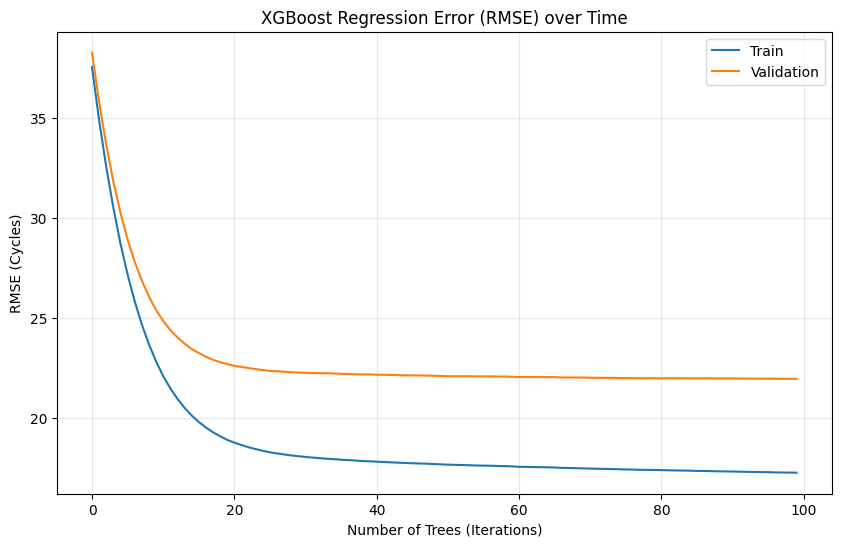

In [26]:
plot_training_curves(model_v0)

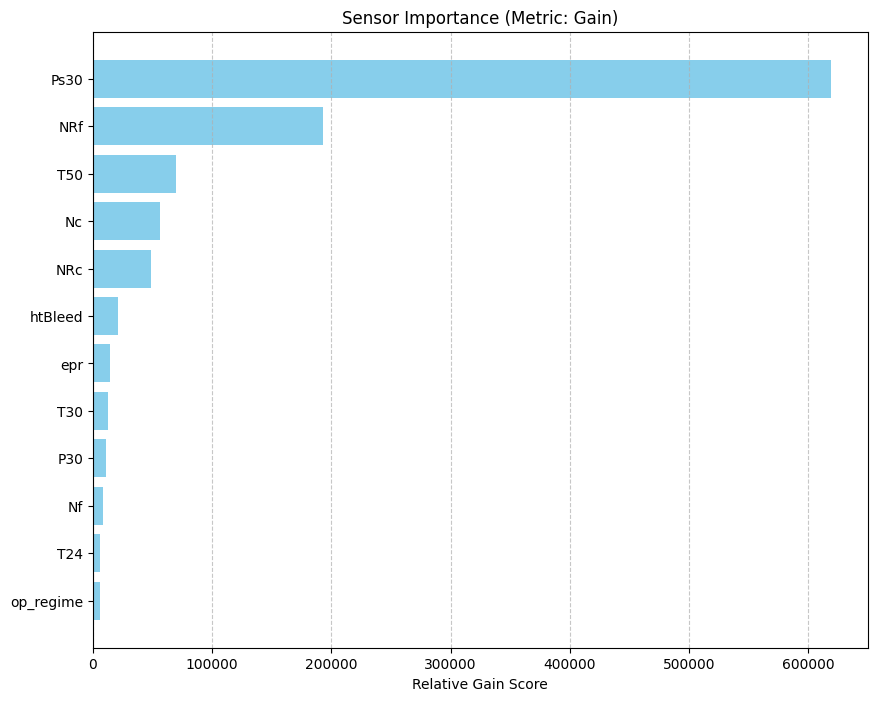

In [23]:
plot_feature_importance(model_v0, importance_type='gain')

In [51]:
X_test, y_true_test = xgboost_test_loader(test_path=test_processed_path, rul_path=rul_test_raw_path, is_snapshot=True)

In [52]:
X_test.head()

,op_regime,T24,T30,T50,P30,Nf,Nc,epr,Ps30,NRf,NRc,htBleed
0,3,2.387600,0.625155,-0.048476,0.764574,1.178267,0.677865,0.156857,0.755679,0.983453,1.051476,0.819026
1,5,-0.599988,-0.346311,0.844946,-0.766956,-0.829606,-1.216676,-0.412956,1.063334,-1.460530,-0.592163,-0.324422
2,5,-0.764343,-1.823840,-0.770845,-0.758468,-0.764099,-0.307035,-0.412956,-0.535059,0.272107,0.609567,-0.767811
3,3,-1.758392,-1.234550,-1.102417,-0.129600,-0.103654,-0.122562,0.156857,-0.488127,-0.046470,0.057184,-0.574973
4,3,1.610227,0.503123,0.768730,-0.225748,-0.246089,-0.175221,0.156857,1.750724,-0.315145,-0.358240,0.122026


In [53]:
y_true_test.head()

,true_rul
0,22
1,39
2,107
3,75
4,149


In [42]:
y_pred_test, test_rmse_v0 = eval_rmse(model_v0, X_test, y_true_test)

Final Test RMSE on FD004: 32.24 cycles


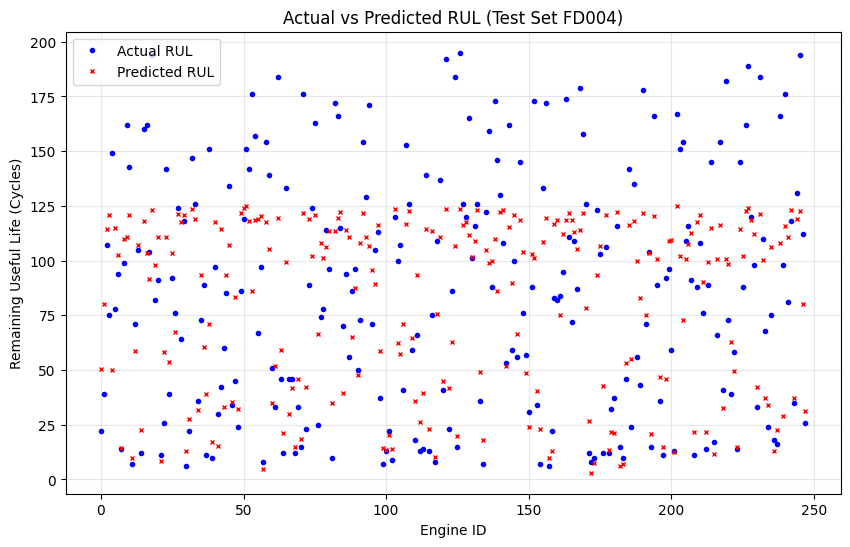

In [54]:
plot_test_results(y_true_test, y_pred_test)

In [100]:
X_test_global, y_true_test_global = xgboost_test_loader(test_path=test_processed_path, rul_path=rul_test_raw_path, is_snapshot=False)

In [101]:
X_test_global.head()

,op_regime,T24,T30,T50,P30,Nf,Nc,epr,Ps30,NRf,NRc,htBleed
0,4,-1.291915,-0.371015,-2.446687,-1.269631,-1.611757,-1.362157,-1.406369,-1.804340,-1.670162,-1.185586,-1.682075
1,3,-1.343792,-0.773920,-2.045346,-1.254529,-0.958268,-1.064417,-5.356662,-2.395297,-0.986834,-1.234205,-0.574973
2,5,-0.844843,-1.929621,-2.206859,-0.829324,-0.784687,-1.434780,-1.857537,-1.555309,-0.594211,-0.717547,-1.654590
3,5,-0.858260,-1.978531,-2.054655,-0.833384,-0.792173,-1.626606,-1.857537,-0.841134,-0.782542,-0.296344,-1.654590
4,5,1.124059,-0.461192,-0.892168,1.222563,1.232928,-0.310538,-0.412956,-2.235476,-0.895540,-1.439453,0.562357


In [102]:
y_true_test_global.head()

0    251
1    250
2    249
3    248
4    247
Name: true_rul_actual, dtype: int64

In [106]:
global_rmse, y_pred_test_global = eval_rmse(model_v0, X_test_global, y_true_test_global)

Final Test RMSE on FD004: 109.72 cycles
